# Домашнее задание №8 «Оптимизация работы с Olivetti»

**Студент**: Сизиков Константин

**Цель**: Цель этого домашнего задания — попробовать использование разных классификаторов в качестве Feature Matching.

**Описание/Пошаговая инструкция выполнения домашнего задания**:
 - Взять код из занятия.
 - Добавить свою Сеть/Модель в конец.
 - Обучить свой классификатор на PCA датасете.

## 0. Окружение и импорты

In [ ]:
import os
import time
import warnings

import numpy as np                 # Работа с алгеброй
import pandas as pd                # Обработка данных

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedShuffleSplit,
                                     RepeatedStratifiedKFold, cross_val_score)
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn import metrics

# DL — своя модель
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
import sklearn; print("scikit-learn:", sklearn.__version__)
print("torch       :", torch.__version__)

In [2]:
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

device: cuda | NVIDIA GeForce RTX 3090


## 1. Датасет Olivetti

Описание:

* Все изображения взяты между 1992 и 1994 годами.
* 40 людей, 10 изображений каждого.
* Это результирует в 400 изображениях
* Изображения были сняты в разное время, с разным освещением и с разным поворотом головы
* На всех изображениях черный задник
* Изображения нормализованны по высоте
* Размер изображения 64x64
* Значения пикселей изображений нормированны в [0, 1]
* Каждому человеку был присвоен номер от 0 до 39

In [ ]:
DATA_DIR = "examples"   # .npy лежат рядом с исходным ноутбуком

data = np.load(os.path.join(DATA_DIR, "olivetti_faces.npy"))
target = np.load(os.path.join(DATA_DIR, "olivetti_faces_target.npy"))

print("data  :", data.shape, data.dtype)
print("target:", target.shape, target.dtype)

In [ ]:
print("There are {} images in the dataset".format(len(data)))
print("There are {} unique targets in the dataset".format(len(np.unique(target))))
print("Size of each image is {}x{}".format(data.shape[1], data.shape[2]))
print("Pixel values were scaled to [0,1] interval. e.g:{}".format(data[0][0, :4]))
print("unique target number:", np.unique(target))

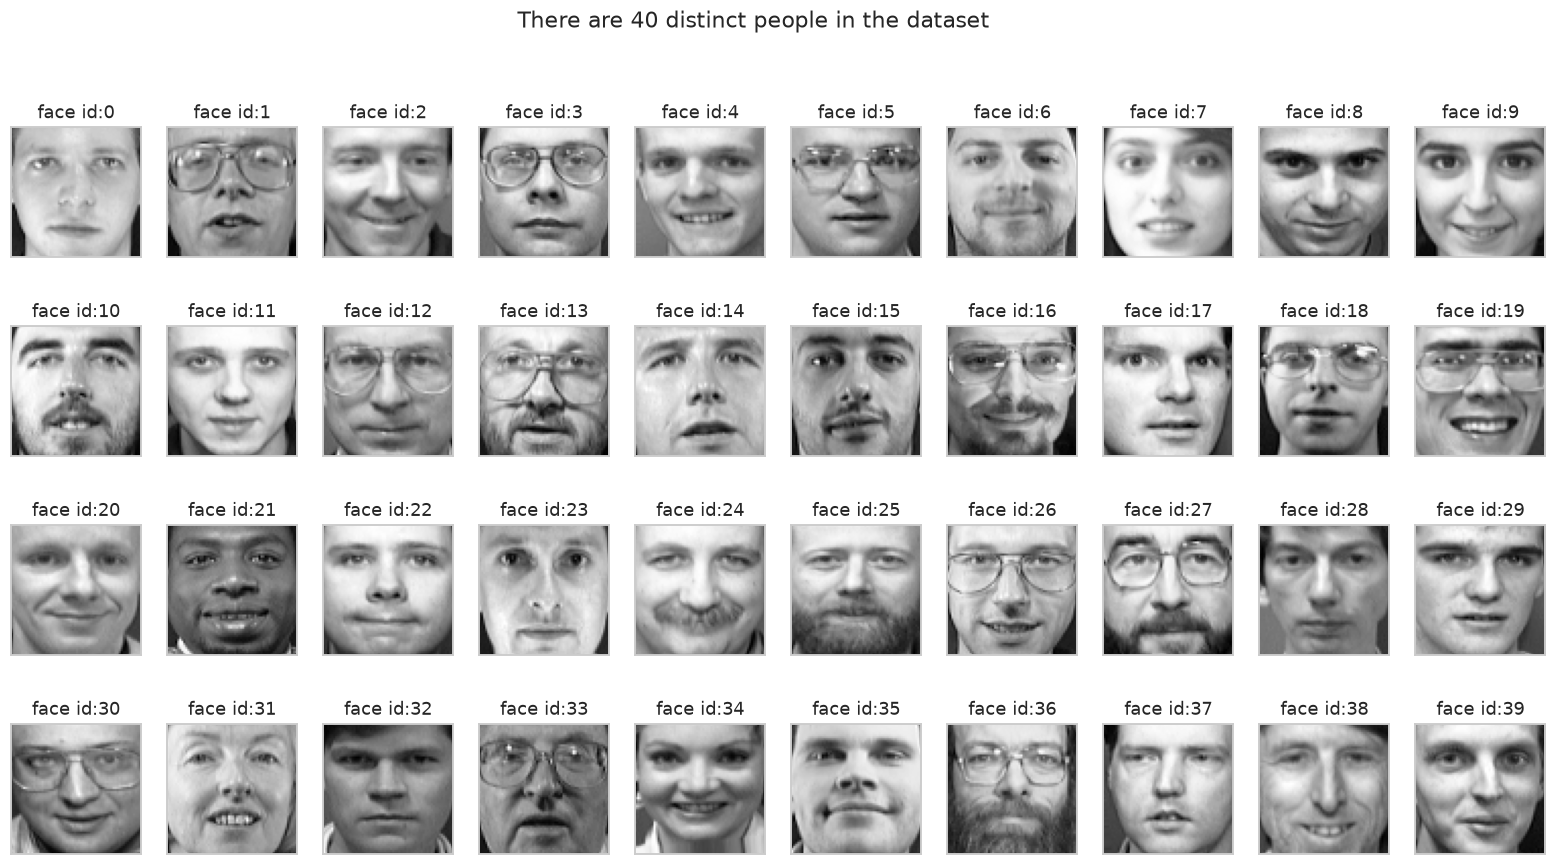

In [5]:
def show_40_distinct_people(images, unique_ids):
    '''Сетка 4x10: по одному лицу каждого из 40 человек.'''
    fig, axarr = plt.subplots(nrows=4, ncols=10, figsize=(18, 9))
    axarr = axarr.flatten()

    for unique_id in unique_ids:
        image_index = unique_id * 10
        axarr[unique_id].imshow(images[image_index], cmap="gray")
        axarr[unique_id].set_xticks([])
        axarr[unique_id].set_yticks([])
        axarr[unique_id].set_title("face id:{}".format(unique_id))
    plt.suptitle("There are 40 distinct people in the dataset")
    plt.show()


show_40_distinct_people(data, np.unique(target))

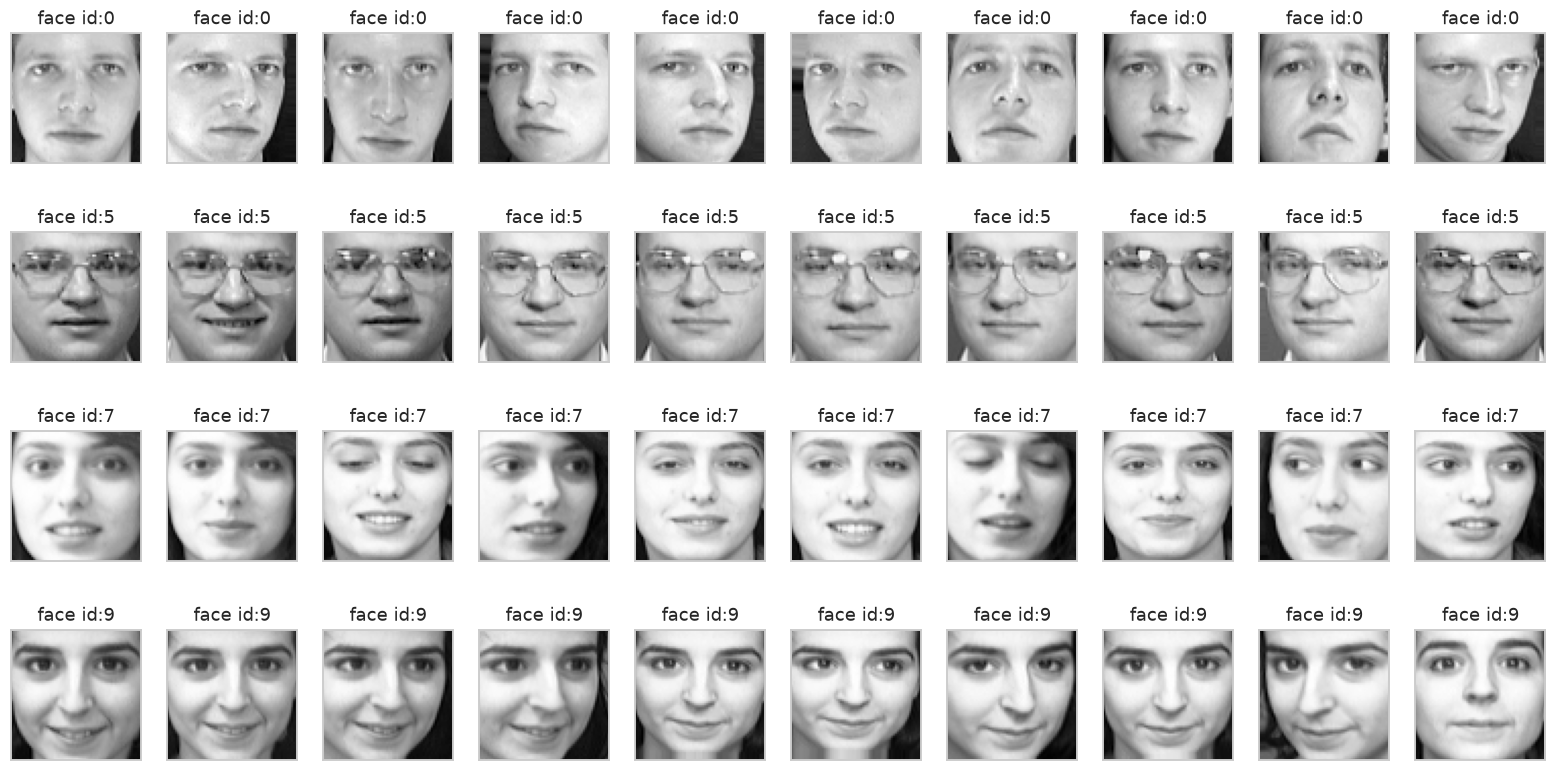

In [6]:
def show_10_faces_of_n_subject(images, subject_ids):
    '''Все 10 снимков для каждого из указанных людей — видно разброс поз и освещения.'''
    cols = 10                      # each subject has 10 distinct face images
    rows = int((len(subject_ids) * 10) / cols)

    fig, axarr = plt.subplots(nrows=rows, ncols=cols, figsize=(18, 9))

    for i, subject_id in enumerate(subject_ids):
        for j in range(cols):
            image_index = subject_id * 10 + j
            axarr[i, j].imshow(images[image_index], cmap="gray")
            axarr[i, j].set_xticks([])
            axarr[i, j].set_yticks([])
            axarr[i, j].set_title("face id:{}".format(subject_id))
    plt.show()


show_10_faces_of_n_subject(images=data, subject_ids=[0, 5, 7, 9])

Видно главную сложность датасета: внутриклассовая изменчивость (поворот головы, очки,
мимика, освещение) заметно больше, чем можно было бы ожидать при 7 обучающих снимках
на человека. Именно поэтому «сырые» пиксели — плохое пространство для сопоставления,
и нужен PCA.

## 2. Подготовка данных

Разворачиваем каждое изображение 64×64 в вектор длины 4096 и делим на train/test
со стратификацией по человеку: 7 снимков в train и 3 в test на каждого.

In [7]:
X = data.reshape((data.shape[0], data.shape[1] * data.shape[2]))
print("X shape:", X.shape)

X shape: (400, 4096)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, target, test_size=0.3, stratify=target, random_state=0)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("y_train shape:{}".format(y_train.shape))
print("снимков на человека: train = {}, test = {}".format(
    np.bincount(y_train).min(), np.bincount(y_test).min()))

X_train shape: (280, 4096)
X_test  shape: (120, 4096)
y_train shape:(280,)
снимков на человека: train = 7, test = 3


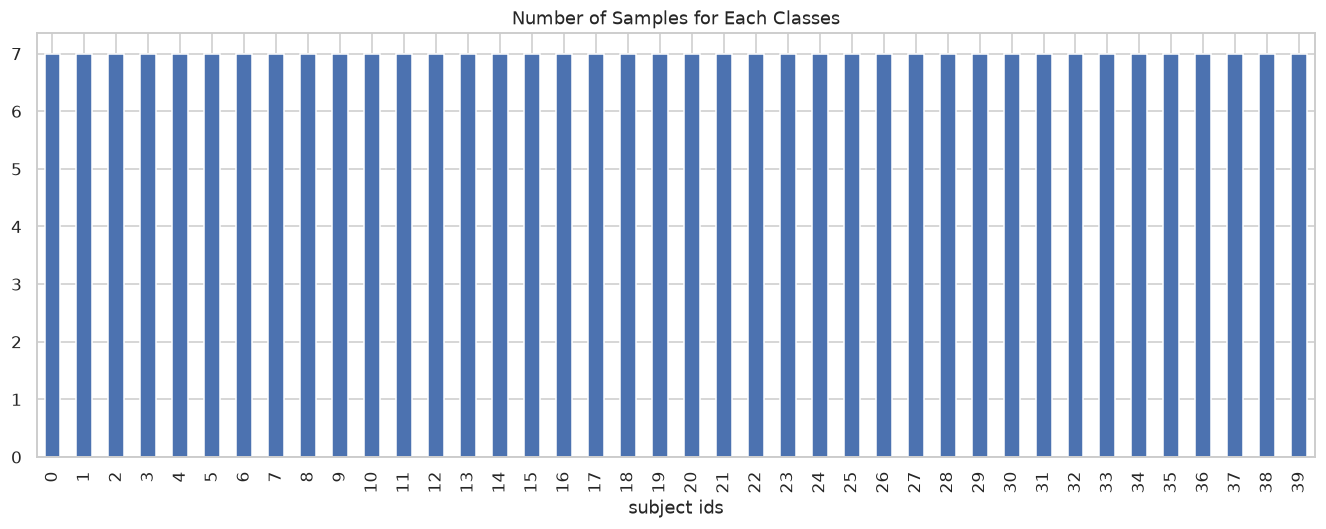

In [9]:
y_frame = pd.DataFrame()
y_frame["subject ids"] = y_train
y_frame.groupby(["subject ids"]).size().plot.bar(
    figsize=(15, 5), title="Number of Samples for Each Classes")
plt.show()

## 3. PCA — eigenfaces как Feature Extractor

PCA играет роль извлечения признаков: 4096 пикселей → несколько десятков компонент.
Классификаторы дальше работают уже в этом пространстве, то есть выполняют
*Feature Matching*.

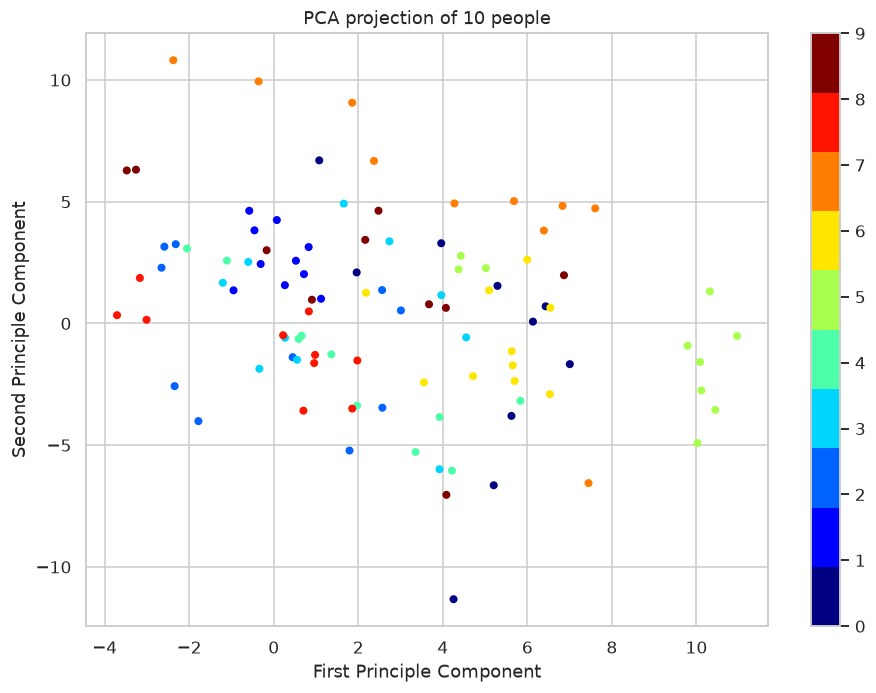

In [10]:
# Проекция на 2 главные компоненты — только для наглядности
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

number_of_people = 10
index_range = number_of_people * 10

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(1, 1, 1)
scatter = ax.scatter(X_pca_2d[:index_range, 0],
                     X_pca_2d[:index_range, 1],
                     c=target[:index_range],
                     s=18,
                     cmap=plt.get_cmap("jet", number_of_people))
ax.set_xlabel("First Principle Component")
ax.set_ylabel("Second Principle Component")
ax.set_title("PCA projection of {} people".format(number_of_people))
fig.colorbar(scatter)
plt.show()

Двух компонент явно мало — классы перемешаны. Смотрим, сколько компонент нужно на самом деле.

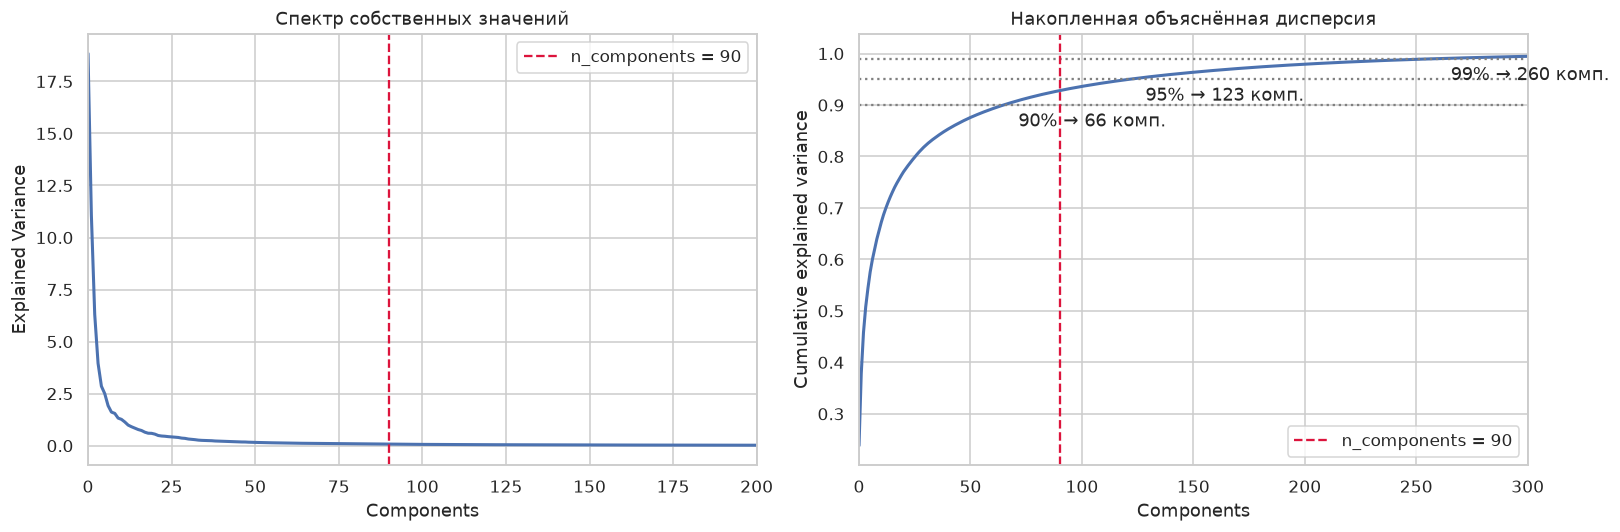

90% дисперсии объясняют 66 компонент
95% дисперсии объясняют 123 компонент
99% дисперсии объясняют 260 компонент
90 компонент объясняют 92.71% дисперсии


In [11]:
pca_full = PCA().fit(X)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(pca_full.explained_variance_, linewidth=2)
ax[0].axvline(90, color="crimson", ls="--", label="n_components = 90")
ax[0].set_xlabel("Components")
ax[0].set_ylabel("Explained Variance")
ax[0].set_title("Спектр собственных значений")
ax[0].set_xlim(0, 200)
ax[0].legend()

ax[1].plot(cum_var, linewidth=2)
for thr in (0.90, 0.95, 0.99):
    k = int(np.searchsorted(cum_var, thr) + 1)
    ax[1].axhline(thr, color="grey", ls=":")
    ax[1].annotate("{:.0%} → {} комп.".format(thr, k), (k, thr),
                   textcoords="offset points", xytext=(8, -14))
ax[1].axvline(90, color="crimson", ls="--", label="n_components = 90")
ax[1].set_xlabel("Components")
ax[1].set_ylabel("Cumulative explained variance")
ax[1].set_title("Накопленная объяснённая дисперсия")
ax[1].set_xlim(0, 300)      # чтобы отметка 99 % (260 компонент) попала в кадр
ax[1].legend()

plt.tight_layout()
plt.show()

for thr in (0.90, 0.95, 0.99):
    print("{:.0%} дисперсии объясняют {} компонент".format(
        thr, int(np.searchsorted(cum_var, thr) + 1)))
print("90 компонент объясняют {:.2%} дисперсии".format(cum_var[89]))

По графику видно, что увеличение количества компонент выше ~90 не даёт значимого прироста
объяснённой дисперсии — берём `n_components = 90`, как в исходном ноутбуке.

In [12]:
n_components = 90

pca = PCA(n_components=n_components, whiten=True, random_state=SEED)
pca.fit(X_train)          # важно: PCA обучается ТОЛЬКО на train

print("объяснённая дисперсия {} компонентами: {:.2%}".format(
    n_components, pca.explained_variance_ratio_.sum()))

объяснённая дисперсия 90 компонентами: 93.75%


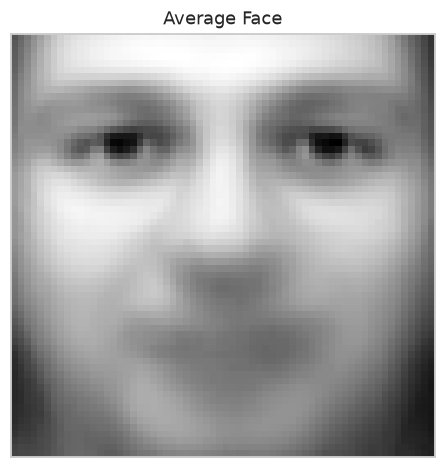

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(pca.mean_.reshape((64, 64)), cmap="gray")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Average Face")
plt.show()

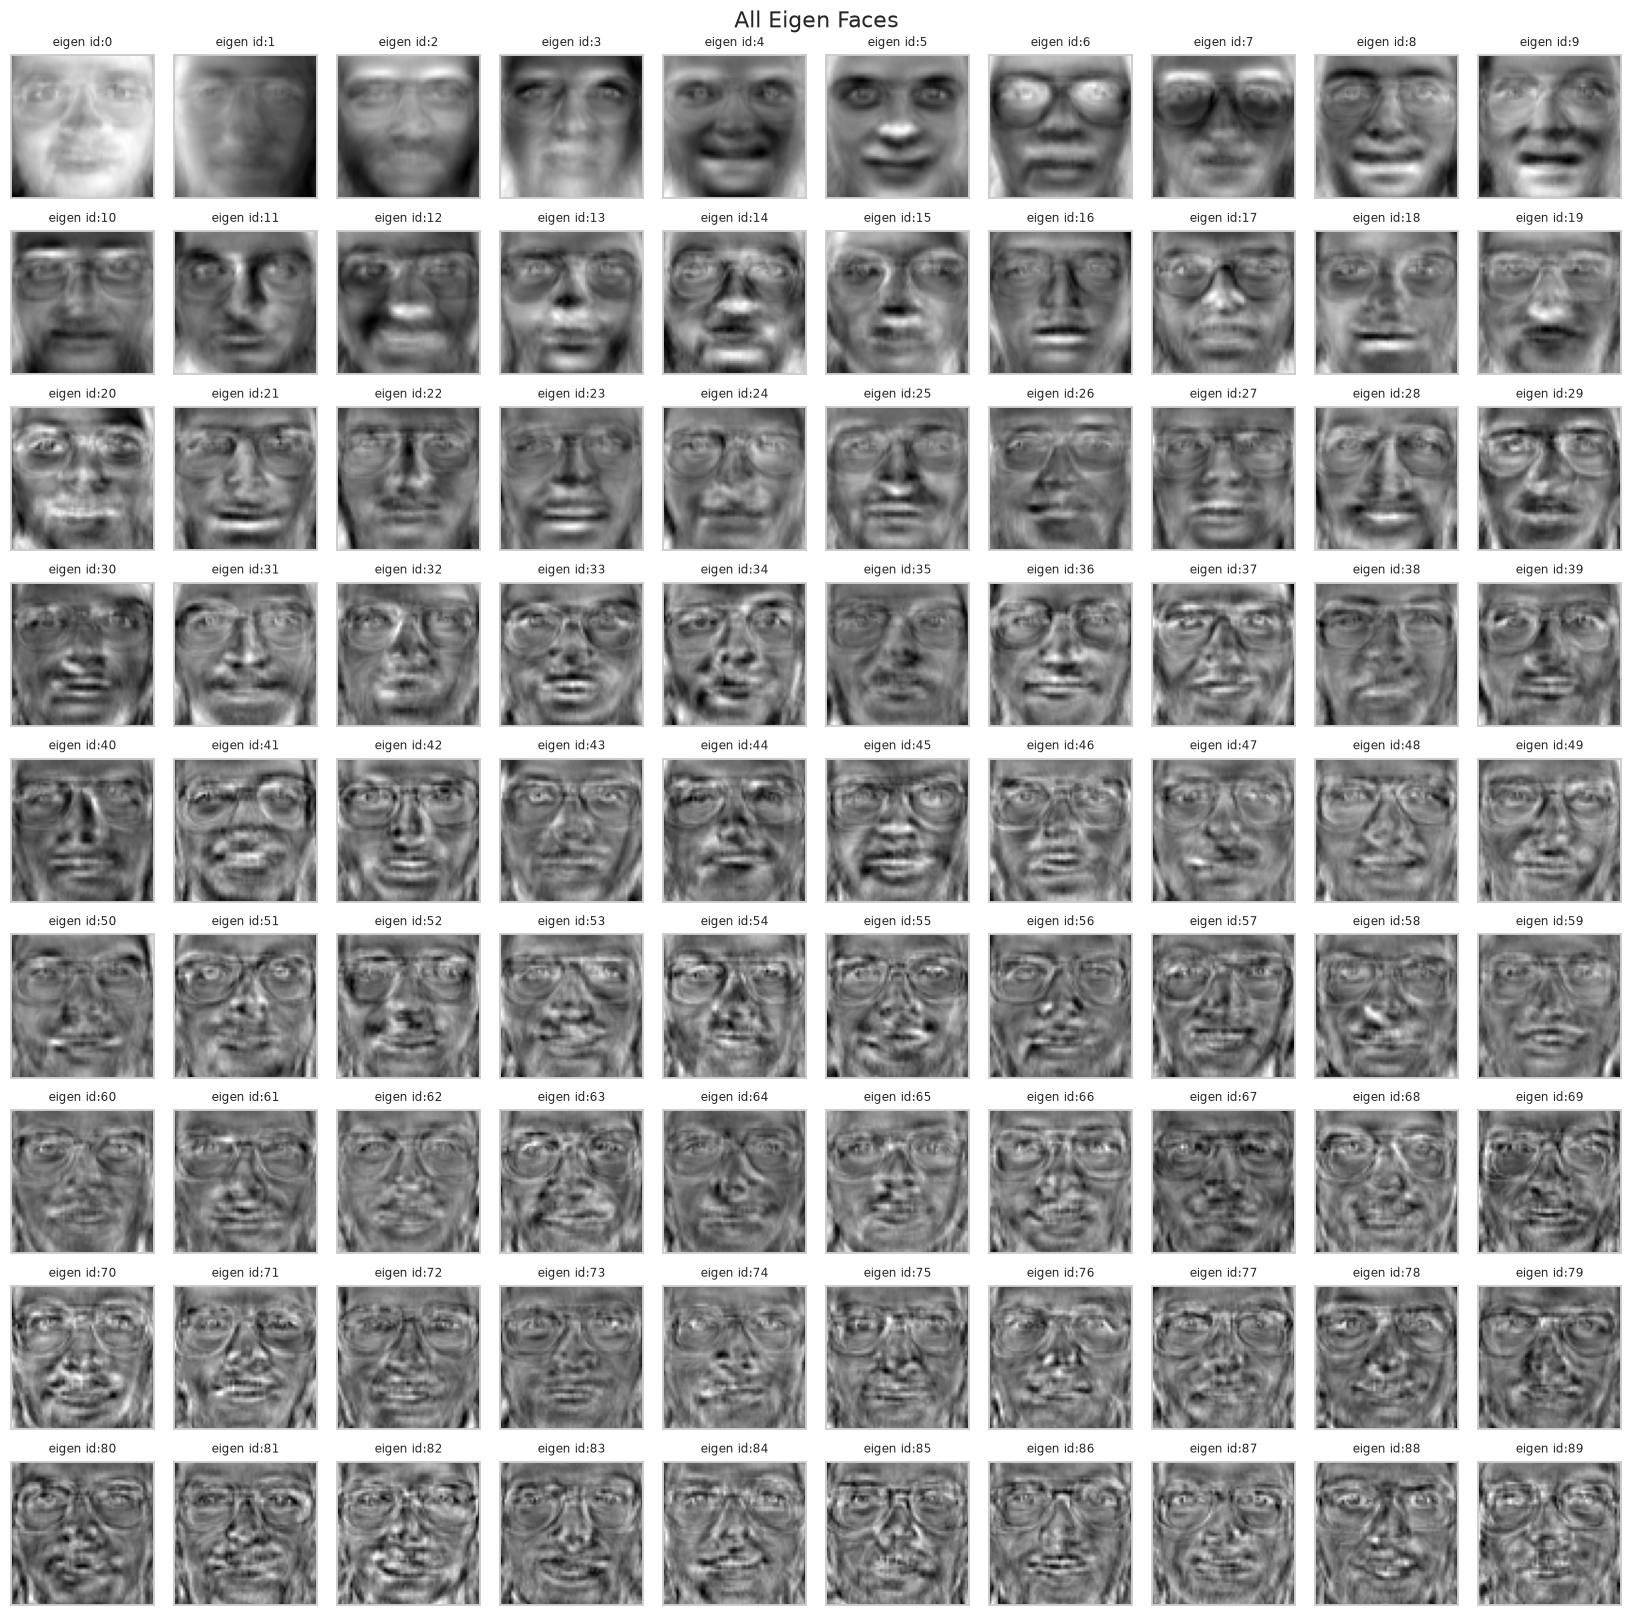

In [14]:
number_of_eigenfaces = len(pca.components_)
eigen_faces = pca.components_.reshape(
    (number_of_eigenfaces, data.shape[1], data.shape[2]))

cols = 10
rows = int(number_of_eigenfaces / cols)
fig, axarr = plt.subplots(nrows=rows, ncols=cols, figsize=(15, 15))
axarr = axarr.flatten()
for i in range(number_of_eigenfaces):
    axarr[i].imshow(eigen_faces[i], cmap="gray")
    axarr[i].set_xticks([]); axarr[i].set_yticks([])
    axarr[i].set_title("eigen id:{}".format(i), fontsize=8)
plt.suptitle("All Eigen Faces")
plt.tight_layout()
plt.show()

In [15]:
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

print("X_train_pca:", X_train_pca.shape)
print("X_test_pca :", X_test_pca.shape)
print("сжатие признаков: {} → {} ({:.1f}x)".format(
    X_train.shape[1], X_train_pca.shape[1], X_train.shape[1] / X_train_pca.shape[1]))

X_train_pca: (280, 90)
X_test_pca : (120, 90)
сжатие признаков: 4096 → 90 (45.5x)


Первые собственные лица кодируют освещение и общую форму головы, дальние — мелкие детали
(очки, границы волос). 90 компонент — это сжатие в 45.5 раза при сохранении 93.7 % дисперсии
обучающей выборки (92.7 %, если считать PCA по всем 400 снимкам).

## 4. Feature Matching: классические классификаторы

### 4.1 Базовая линия из исходного ноутбука

In [16]:
clf = SVC()
clf.fit(X_train_pca, y_train)
y_pred = clf.predict(X_test_pca)
baseline_acc = metrics.accuracy_score(y_test, y_pred)
print("SVC (defaults) accuracy score:{:.2f}".format(baseline_acc))

SVC (defaults) accuracy score:0.92


### 4.2 Подбор гиперпараметров

Сначала попробуем классификаторы из классического ML: логистическую регрессию,
K-ближайших соседей и случайный лес — и добавим к ним ещё три, которые хорошо ложатся
на задачу сопоставления признаков:

* **`SVC` с подбором `C`/`gamma`/ядра** — базовый метод для eigenfaces;
* **`NearestCentroid`** — «честный» Feature Matching: класс = ближайший средний
  вектор-шаблон человека в PCA-пространстве, без обучаемых параметров;
* **`LinearDiscriminantAnalysis` (Fisherfaces)** — в ноутбуке урока он импортирован,
  но не использован; PCA + LDA — классическая связка, которая ищет проекцию, максимально
  разделяющую классы, а не максимизирующую дисперсию.

Сетки для случайного леса в исходном ноутбуке дают 3724 комбинации × 5 фолдов ≈ 18 620
обучений — это минуты впустую на 280 объектах. Ужимаем сетки до разумных и включаем `n_jobs=-1`.

In [ ]:
SEARCH_SPACES = {
    "SVC": (
        SVC(random_state=SEED),
        {"kernel": ["linear", "rbf"],
         "C": [0.1, 1, 10, 100, 1000],
         "gamma": ["scale", 1e-4, 1e-3, 1e-2]},
    ),
    "LogReg": (
        LogisticRegression(max_iter=2000, random_state=SEED),
        {"C": [0.01, 0.1, 1, 10, 100]},
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"n_neighbors": [1, 3, 5, 7],
         "weights": ["uniform", "distance"],
         "metric": ["euclidean", "cosine"]},
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=SEED, n_jobs=1),
        {"n_estimators": [200, 500],
         "max_depth": [None, 10, 20],
         "min_samples_leaf": [1, 2],
         "max_features": ["sqrt", 0.2]},
    ),
    "NearestCentroid": (
        NearestCentroid(),
        {"metric": ["euclidean", "manhattan"]},
    ),
    "LDA (Fisherfaces)": (
        LinearDiscriminantAnalysis(),
        # n_components у LDA влияет только на transform, но не на predict,
        # поэтому подбираем то, что реально меняет решающее правило: solver и shrinkage
        [{"solver": ["svd"]},
         {"solver": ["lsqr", "eigen"], "shrinkage": [None, "auto", 0.1, 0.5]}],
    ),
}

In [18]:
results = []
best_estimators = {}

for name, (estimator, grid) in SEARCH_SPACES.items():
    t0 = time.time()
    search = GridSearchCV(estimator, grid, cv=5, n_jobs=-1, scoring="accuracy")
    search.fit(X_train_pca, y_train)
    fit_time = time.time() - t0

    y_hat = search.best_estimator_.predict(X_test_pca)
    acc = metrics.accuracy_score(y_test, y_hat)

    best_estimators[name] = search.best_estimator_
    results.append({
        "model": name,
        "cv_acc": search.best_score_,
        "test_acc": acc,
        "fit_sec": fit_time,
        "n_fits": len(search.cv_results_["params"]) * 5,
        "best_params": search.best_params_,
    })
    print("{:<18} cv={:.3f}  test={:.3f}  ({:5.1f} c, {} обучений)  {}".format(
        name, search.best_score_, acc, fit_time,
        results[-1]["n_fits"], search.best_params_))

SVC                cv=0.918  test=0.925  (  3.5 c, 200 обучений)  {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
LogReg             cv=0.936  test=0.917  (  0.0 c, 25 обучений)  {'C': 1}
KNN                cv=0.918  test=0.908  (  0.1 c, 80 обучений)  {'metric': 'cosine', 'n_neighbors': 1, 'weights': 'uniform'}


RandomForest       cv=0.925  test=0.925  ( 12.6 c, 120 обучений)  {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}
NearestCentroid    cv=0.836  test=0.908  (  0.0 c, 10 обучений)  {'metric': 'euclidean'}
LDA (Fisherfaces)  cv=0.971  test=0.917  (  0.1 c, 45 обучений)  {'solver': 'svd'}


In [19]:
classic_df = (pd.DataFrame(results)
              .sort_values("test_acc", ascending=False)
              .reset_index(drop=True))
classic_df[["model", "cv_acc", "test_acc", "fit_sec"]].round(3)

,model,cv_acc,test_acc,fit_sec
0,SVC,0.918,0.925,3.460
1,RandomForest,0.925,0.925,12.584
2,LogReg,0.936,0.917,0.043
3,LDA (Fisherfaces),0.971,0.917,0.140
4,KNN,0.918,0.908,0.127
5,NearestCentroid,0.836,0.908,0.014


### 4.3 Устойчивость результата: вложенная кросс-валидация

Одно случайное разбиение на 120 тестовых объектов — это шаг точности 0.83 %,
и разница «0.97 против 0.96» на нём ничего не значит. Нужна оценка по многим разбиениям.

Но просто прогнать по CV уже настроенные модели из ячейки выше **нельзя**: их
гиперпараметры подбирались на тех же 280 объектах, которые потом попадут в тестовые
фолды. Это утечка — оценка получится завышенной.

Поэтому делаем **вложенную кросс-валидацию**: весь конвейер
`PCA → GridSearchCV(классификатор)` целиком кладём внутрь внешней CV.
На каждом из 20 внешних фолдов PCA обучается заново, гиперпараметры подбираются заново
по внутренней 3-фолдовой CV, и только потом модель встречается с тестовым фолдом.
Тестовые данные не участвуют ни в PCA, ни в подборе — утечки нет ни на одном шаге.


In [ ]:
INNER_CV = 3      # внутренняя CV — подбор гиперпараметров внутри каждого внешнего фолда

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=SEED)
cv_rows = []
cv_scores_raw = {}        # пофолдовые оценки — нужны для попарного сравнения ниже

t_all = time.time()
for name, (estimator, grid) in SEARCH_SPACES.items():
    # GridSearchCV — часть конвейера, поэтому подбор происходит внутри внешнего фолда
    pipe = Pipeline([
        ("pca", PCA(n_components=n_components, whiten=True, random_state=SEED)),
        ("clf", GridSearchCV(estimator, grid, cv=INNER_CV, scoring="accuracy")),
    ])
    t0 = time.time()
    scores = cross_val_score(pipe, X, target, cv=cv, scoring="accuracy", n_jobs=-1)
    cv_scores_raw[name] = scores
    cv_rows.append({"model": name, "cv_mean": scores.mean(), "cv_std": scores.std()})
    print("{:<18} {:.4f} ± {:.4f}   ({:.1f} c)".format(
        name, scores.mean(), scores.std(), time.time() - t0))

print("\nвложенная CV целиком: {:.0f} c".format(time.time() - t_all))
cv_df = pd.DataFrame(cv_rows).sort_values("cv_mean", ascending=False).reset_index(drop=True)

In [ ]:
plot_df = cv_df.sort_values("cv_mean")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(plot_df["model"], plot_df["cv_mean"],
        xerr=plot_df["cv_std"], color="#4C72B0", alpha=.9, capsize=4)
for y_i, (m, s) in enumerate(zip(plot_df["cv_mean"], plot_df["cv_std"])):
    ax.text(m + s + 0.005, y_i, "{:.3f}".format(m), va="center", fontsize=9)
ax.set_xlim(0.5, 1.03)
ax.set_xlabel("accuracy (вложенная CV: внешняя 5×4, внутренняя 3)")
ax.set_title("Классификаторы как Feature Matching поверх PCA-90")
plt.tight_layout()
plt.show()

## 5. Своя модель: `EigenFaceMLP` на PyTorch

Реализуем свою сеть на PyTorch с учетом специфики задачи. Из 280 обучающих объектов
40 откладываем на валидацию, так что **сеть учится на 240 векторах для 40 классов —
по 6 примеров на класс**. Чтобы избежать переобучения сделаем архитектуру скромной, а регуляризацию — агрессивной:

* вход — 90 whitened PCA-компонент (уже нормированы, отдельный скейлер не нужен);
* два скрытых слоя 256 → 128, `ELU`, `BatchNorm`, `Dropout 0.4`;
* **аугментация прямо в пространстве признаков**: к PCA-вектору добавляется гауссов шум
  σ = 0.15. Для whitened-компонент это корректный аналог лёгкого искажения лица
  и главный источник дополнительной вариативности, которого нет в 6 снимках;
* `AdamW` (weight decay 1e-2) + косинусный отжиг LR;
* `CrossEntropyLoss` с `label_smoothing=0.05`;
* **валидационный сплит** (по 1 снимку на человека, 40 объектов): по нему выбирается
  лучший чекпоинт и срабатывает ранняя остановка — **по val-loss, а не по val-accuracy**.
  В валидации всего 40 объектов, поэтому точность меняется шагами по 2.5 %, десятки эпох
  дают одно и то же значение, и «лучшей» оказывается первая попавшаяся ранняя эпоха;
  лосс непрерывен и различает их. Тест используется ровно один раз, в самом конце.



In [ ]:
# Валидационный сплит: по одному снимку каждого человека (40 объектов)
sss = StratifiedShuffleSplit(n_splits=1, test_size=40, random_state=SEED)
tr_idx, val_idx = next(sss.split(X_train_pca, y_train))

X_tr, y_tr = X_train_pca[tr_idx], y_train[tr_idx]
X_val, y_val = X_train_pca[val_idx], y_train[val_idx]

print("train: {}, val: {}, test: {}".format(len(X_tr), len(X_val), len(X_test_pca)))

In [ ]:
def to_tensor(X_, y_):
    return (torch.tensor(X_, dtype=torch.float32),
            torch.tensor(y_, dtype=torch.long))


Xt_tr, yt_tr = to_tensor(X_tr, y_tr)
Xt_val, yt_val = to_tensor(X_val, y_val)
Xt_test, yt_test = to_tensor(X_test_pca, y_test)

train_loader = DataLoader(TensorDataset(Xt_tr, yt_tr), batch_size=32,
                          shuffle=True, drop_last=False)

Xt_val, yt_val = Xt_val.to(DEVICE), yt_val.to(DEVICE)
Xt_test, yt_test = Xt_test.to(DEVICE), yt_test.to(DEVICE)

In [24]:
class EigenFaceMLP(nn.Module):
    '''MLP-классификатор поверх PCA-признаков лица.

    noise_std — аугментация в пространстве eigenfaces: активна только в train-режиме.
    '''

    def __init__(self, in_features=90, n_classes=40, hidden=(256, 128),
                 p_drop=0.4, noise_std=0.15):
        super().__init__()
        self.noise_std = noise_std

        layers, prev = [], in_features
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ELU(), nn.Dropout(p_drop)]
            prev = h
        self.body = nn.Sequential(*layers)
        self.head = nn.Linear(prev, n_classes)

    def forward(self, x):
        if self.training and self.noise_std > 0:
            x = x + torch.randn_like(x) * self.noise_std
        return self.head(self.body(x))


model = EigenFaceMLP(in_features=n_components).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print("\nобучаемых параметров: {:,}".format(n_params))

EigenFaceMLP(
  (body): Sequential(
    (0): Linear(in_features=90, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ELU(alpha=1.0)
    (7): Dropout(p=0.4, inplace=False)
  )
  (head): Linear(in_features=128, out_features=40, bias=True)
)

обучаемых параметров: 62,120


In [25]:
EPOCHS = 200      # столько же, сколько в кросс-валидационной версии ниже
PATIENCE = 60

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


@torch.no_grad()
def evaluate(net, X_, y_):
    net.eval()
    logits = net(X_)
    # тот же criterion, что и на обучении: label smoothing поднимает лосс примерно
    # на 0.37, и если считать val обычной cross_entropy, кривые окажутся
    # в разных шкалах и графики train/val будут несопоставимы
    loss = criterion(logits, y_).item()
    acc = (logits.argmax(1) == y_).float().mean().item()
    return loss, acc


history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
# отбор чекпоинта по val-LOSS, а не по val-accuracy: в валидации всего 40 объектов,
# то есть точность меняется шагами по 2.5 % и на ней десятки эпох дают одно и то же
# значение — «лучшей» становится случайная ранняя эпоха. Лосс непрерывен и различает их.
best_loss, best_epoch, best_state, since_best = float("inf"), -1, None, 0

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    run_loss, run_correct, seen = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        run_loss += loss.item() * xb.size(0)
        run_correct += (logits.argmax(1) == yb).sum().item()
        seen += xb.size(0)
    scheduler.step()

    val_loss, val_acc = evaluate(model, Xt_val, yt_val)
    history["train_loss"].append(run_loss / seen)
    history["train_acc"].append(run_correct / seen)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_loss < best_loss:
        best_loss, best_epoch, since_best = val_loss, epoch, 0
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
    else:
        since_best += 1

    if epoch % 25 == 0 or epoch == 1:
        print("epoch {:>3} | train loss {:.4f} acc {:.3f} | val loss {:.4f} acc {:.3f}".format(
            epoch, history["train_loss"][-1], history["train_acc"][-1], val_loss, val_acc))

    if since_best >= PATIENCE:
        print("ранняя остановка на эпохе {} (без улучшения {} эпох)".format(epoch, PATIENCE))
        break

train_time = time.time() - t0
model.load_state_dict(best_state)
print("\nобучение заняло {:.1f} c; лучший чекпоинт — эпоха {} "
      "(val loss {:.4f}, val accuracy {:.3f})".format(
          train_time, best_epoch, best_loss, history["val_acc"][best_epoch - 1]))

epoch   1 | train loss 3.5426 acc 0.133 | val loss 3.1189 acc 0.525


epoch  25 | train loss 0.4572 acc 1.000 | val loss 0.7539 acc 0.925


epoch  50 | train loss 0.4415 acc 1.000 | val loss 0.7563 acc 0.925


epoch  75 | train loss 0.4349 acc 1.000 | val loss 0.7287 acc 0.950


epoch 100 | train loss 0.4263 acc 1.000 | val loss 0.7257 acc 0.950
ранняя остановка на эпохе 118 (без улучшения 60 эпох)

обучение заняло 1.5 c; лучший чекпоинт — эпоха 58 (val loss 0.7138, val accuracy 0.950)


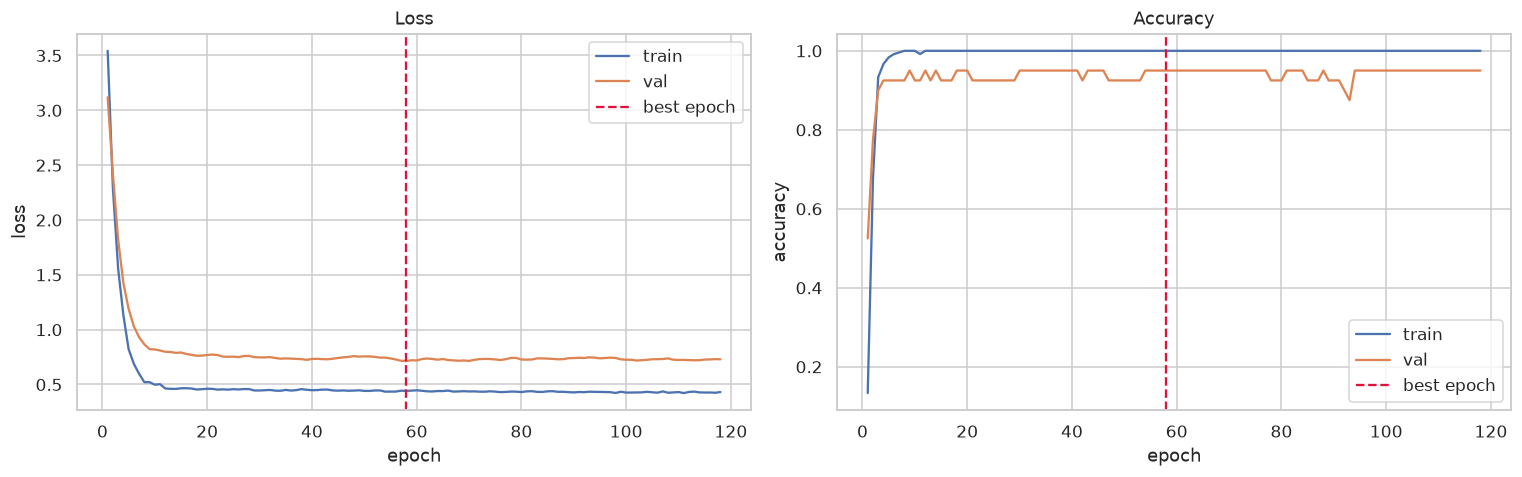

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
epochs_axis = range(1, len(history["train_loss"]) + 1)

ax[0].plot(epochs_axis, history["train_loss"], label="train")
ax[0].plot(epochs_axis, history["val_loss"], label="val")
ax[0].axvline(best_epoch, color="crimson", ls="--", label="best epoch")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].set_title("Loss")
ax[0].legend()

ax[1].plot(epochs_axis, history["train_acc"], label="train")
ax[1].plot(epochs_axis, history["val_acc"], label="val")
ax[1].axvline(best_epoch, color="crimson", ls="--", label="best epoch")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy"); ax[1].set_title("Accuracy")
ax[1].legend()

plt.tight_layout()
plt.show()

In [27]:
test_loss, test_acc_nn = evaluate(model, Xt_test, yt_test)

model.eval()
with torch.no_grad():
    logits_test = model(Xt_test)
    proba_test = logits_test.softmax(1)
    y_pred_nn = logits_test.argmax(1).cpu().numpy()

top3 = proba_test.topk(3, dim=1).indices.cpu().numpy()
top3_acc = np.mean([y in row for y, row in zip(y_test, top3)])

print("EigenFaceMLP — test loss {:.4f} (с label smoothing), "
      "top-1 accuracy {:.3f}, top-3 accuracy {:.3f}".format(
          test_loss, test_acc_nn, top3_acc))

EigenFaceMLP — test loss 0.7445 (с label smoothing), top-1 accuracy 0.917, top-3 accuracy 0.958


### 5.1 Кросс-валидация сети

Чтобы сравнивать сеть с классикой на равных, прогоняем её по тому же внешнему протоколу:
`RepeatedStratifiedKFold` 5×4, PCA переобучается на каждом train-фолде.

Внутри фолда сеть учится фиксированные 200 эпох без валидационного сплита и ранней
остановки — отдельный val-сплит внутри каждого фолда съел бы ещё по снимку с человека.
Архитектура и гиперпараметры сети зафиксированы заранее и автоматическим поиском
по этим данным не подбирались, так что перебирать внутри фолда здесь нечего.

Важная оговорка о сопоставимости: у классики на каждом фолде гиперпараметры
выбираются заново по внутренней CV — и за это она платит, потому что внутренняя
выборка маленькая. У нейронной сети гиперпараметры одни и те же на всех фолдах, то есть
у неё небольшая фора. Поэтому её результат честнее читать как «не хуже классики»,
а не как строгую победу над конкретным методом.

In [ ]:
def fit_predict_mlp(Xtr_raw, ytr, Xte_raw, seed=SEED, epochs=200):
    '''PCA + EigenFaceMLP на одном фолде. Возвращает предсказания для Xte_raw.'''
    torch.manual_seed(seed)

    pca_f = PCA(n_components=n_components, whiten=True, random_state=seed).fit(Xtr_raw)
    Xtr = torch.tensor(pca_f.transform(Xtr_raw), dtype=torch.float32).to(DEVICE)
    Xte = torch.tensor(pca_f.transform(Xte_raw), dtype=torch.float32).to(DEVICE)
    ytr_t = torch.tensor(ytr, dtype=torch.long).to(DEVICE)

    net = EigenFaceMLP(in_features=n_components).to(DEVICE)
    opt = torch.optim.AdamW(net.parameters(), lr=3e-3, weight_decay=1e-2)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.CrossEntropyLoss(label_smoothing=0.05)

    net.train()
    for _ in range(epochs):
        perm = torch.randperm(Xtr.size(0), device=DEVICE)
        for i in range(0, Xtr.size(0), 32):
            idx = perm[i:i + 32]
            opt.zero_grad()
            loss = crit(net(Xtr[idx]), ytr_t[idx])
            loss.backward()
            opt.step()
        sch.step()

    net.eval()
    with torch.no_grad():
        return net(Xte).argmax(1).cpu().numpy()


t0 = time.time()
nn_scores = []
for fold, (tr, te) in enumerate(cv.split(X, target), 1):
    pred = fit_predict_mlp(X[tr], target[tr], X[te], seed=SEED + fold)
    nn_scores.append(metrics.accuracy_score(target[te], pred))
nn_scores = np.array(nn_scores)

print("EigenFaceMLP  {:.4f} ± {:.4f}   ({} фолдов за {:.1f} c)".format(
    nn_scores.mean(), nn_scores.std(), len(nn_scores), time.time() - t0))

## 6. Сравнение

In [ ]:
summary = cv_df.copy()
summary = pd.concat([
    summary,
    pd.DataFrame([{"model": "EigenFaceMLP (наша сеть)",
                   "cv_mean": nn_scores.mean(),
                   "cv_std": nn_scores.std()}]),
], ignore_index=True)

holdout = {r["model"]: r["test_acc"] for r in results}
holdout["EigenFaceMLP (наша сеть)"] = test_acc_nn
summary["holdout_acc"] = summary["model"].map(holdout)

summary = summary.sort_values("cv_mean", ascending=False).reset_index(drop=True)
summary.round(4)

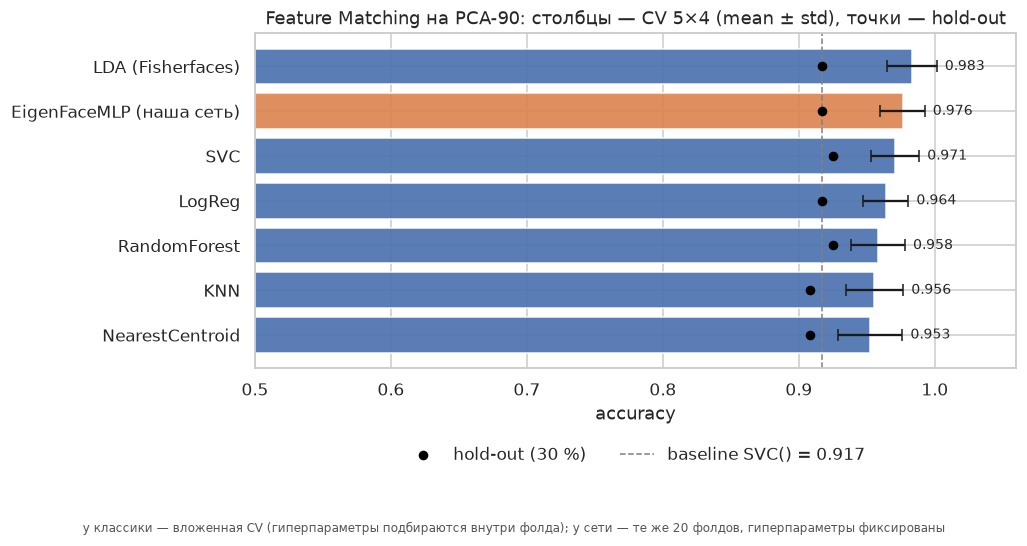

In [30]:
plot_df = summary.sort_values("cv_mean")
colors = ["#DD8452" if "EigenFaceMLP" in m else "#4C72B0" for m in plot_df["model"]]

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.barh(plot_df["model"], plot_df["cv_mean"], xerr=plot_df["cv_std"],
        color=colors, alpha=.92, capsize=4)
ax.scatter(plot_df["holdout_acc"], range(len(plot_df)), color="black",
           zorder=5, s=28, label="hold-out (30 %)")
for y_i, (m, s) in enumerate(zip(plot_df["cv_mean"], plot_df["cv_std"])):
    ax.text(m + s + 0.006, y_i, "{:.3f}".format(m), va="center", fontsize=9)
ax.axvline(baseline_acc, color="grey", ls="--", lw=1,
           label="baseline SVC() = {:.3f}".format(baseline_acc))
ax.set_xlim(0.5, 1.06)
ax.set_xlabel("accuracy")
ax.set_title("Feature Matching на PCA-90: столбцы — CV 5×4 (mean ± std), точки — hold-out")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.19), ncol=2, frameon=False)
fig.text(0.5, 0.015, "у классики — вложенная CV (гиперпараметры подбираются внутри фолда); "
                     "у сети — те же 20 фолдов, гиперпараметры фиксированы",
         ha="center", fontsize=8, color="#555555")
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

### 6.1 Значима ли разница между моделями?

Выше мы отказались ранжировать модели по hold-out, потому что там всё умещается
в два снимка. Но и по «среднее ± std» ранжировать нельзя: std посчитан по фолдам,
а не по разнице между моделями.

Зато все модели прогонялись по **одним и тем же 20 фолдам** (один объект `cv`
с фиксированным `random_state`), поэтому сравнение можно вести **попарно**:
считать разницу на каждом фолде. Это гораздо чувствительнее — общая для обеих моделей
«сложность фолда» сокращается.

Оговорка: фолды в `RepeatedStratifiedKFold` пересекаются между повторами, наблюдения
не независимы, поэтому p-value здесь был бы оптимистично занижен. Ограничимся
описательной статистикой: средняя разница, её разброс и счёт по фолдам.

In [31]:
fold_scores = dict(cv_scores_raw)
fold_scores["EigenFaceMLP (наша сеть)"] = nn_scores

top_model = summary.iloc[0]["model"]
rows = []
for name, sc in fold_scores.items():
    if name == top_model:
        continue
    d = fold_scores[top_model] - sc          # разница на каждом из 20 общих фолдов
    rows.append({
        "против": name,
        "Δ accuracy": d.mean(),
        "std Δ": d.std(),
        "выиграл": int((d > 0).sum()),
        "ничья": int((d == 0).sum()),
        "проиграл": int((d < 0).sum()),
    })

paired = (pd.DataFrame(rows)
          .sort_values("Δ accuracy", ascending=False)
          .reset_index(drop=True))
print("Попарно, «{}» против остальных на 20 общих фолдах:\n".format(top_model))
paired.round(4)

Попарно, «LDA (Fisherfaces)» против остальных на 20 общих фолдах:



,против,Δ accuracy,std Δ,выиграл,ничья,проиграл
0,NearestCentroid,0.0306,0.0187,20,0,0
1,KNN,0.0275,0.0233,17,2,1
2,RandomForest,0.0250,0.0202,17,2,1
3,LogReg,0.0194,0.0192,15,4,1
4,SVC,0.0125,0.0172,12,6,2
5,EigenFaceMLP (наша сеть),0.0069,0.0170,8,10,2


### 6.2 Разбор ошибок лучшей модели

In [32]:
best_name = summary.iloc[0]["model"]
if "EigenFaceMLP" in best_name:
    y_best = y_pred_nn
else:
    y_best = best_estimators[best_name].predict(X_test_pca)

print("лучшая модель по CV:", best_name)
print("\n", metrics.classification_report(y_test, y_best, digits=3, zero_division=0))

лучшая модель по CV: LDA (Fisherfaces)

               precision    recall  f1-score   support

           0      1.000     0.333     0.500         3
           1      1.000     1.000     1.000         3
           2      0.750     1.000     0.857         3
           3      0.750     1.000     0.857         3
           4      0.667     0.667     0.667         3
           5      1.000     1.000     1.000         3
           6      1.000     1.000     1.000         3
           7      1.000     0.667     0.800         3
           8      1.000     1.000     1.000         3
           9      1.000     1.000     1.000         3
          10      1.000     1.000     1.000         3
          11      1.000     1.000     1.000         3
          12      0.333     0.333     0.333         3
          13      1.000     1.000     1.000         3
          14      1.000     1.000     1.000         3
          15      1.000     1.000     1.000         3
          16      1.000     1.000     1.

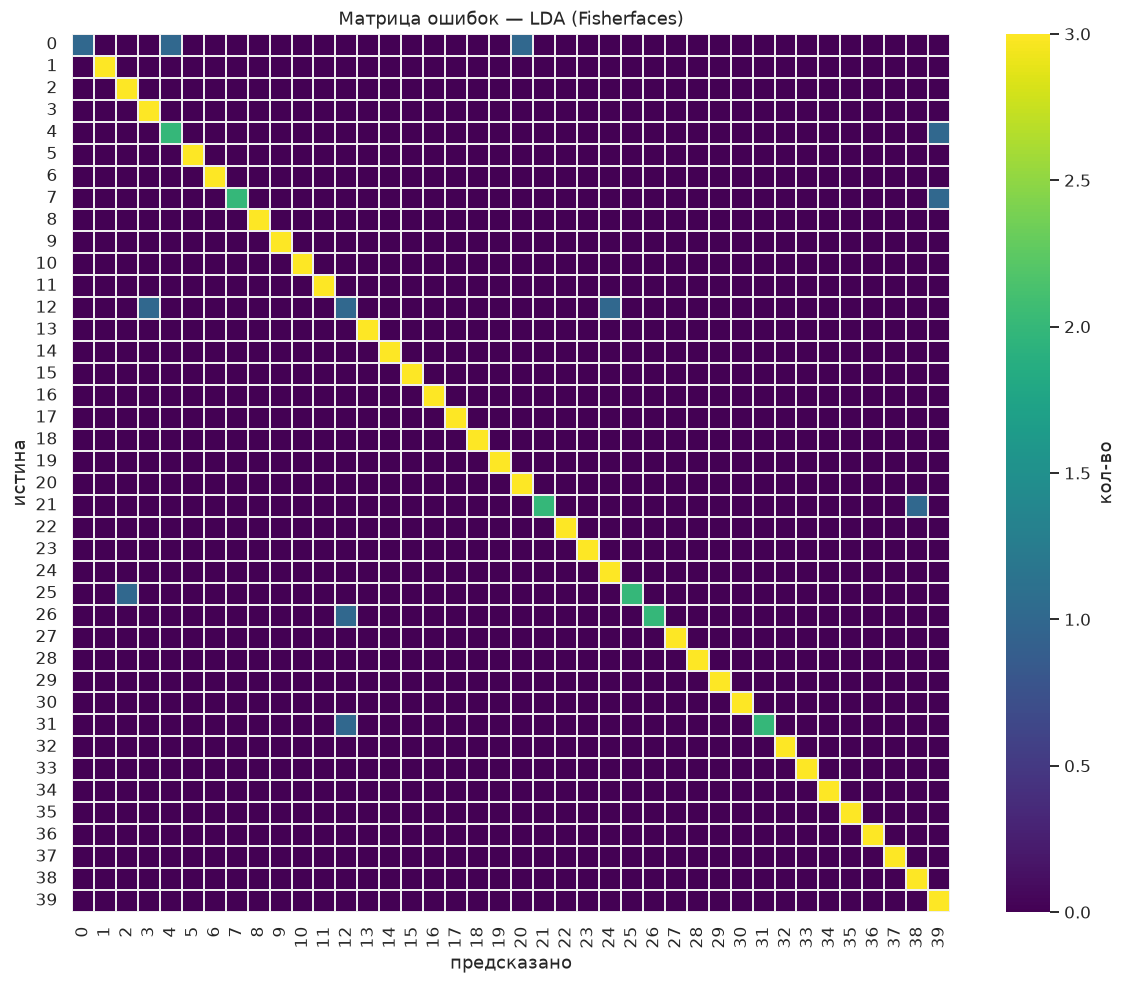

In [33]:
cm = metrics.confusion_matrix(y_test, y_best, labels=np.arange(40))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, cmap="viridis", cbar_kws={"label": "кол-во"}, ax=ax,
            square=True, linewidths=.2, linecolor="#eeeeee")
ax.set_xlabel("предсказано"); ax.set_ylabel("истина")
ax.set_title("Матрица ошибок — {}".format(best_name))
plt.tight_layout()
plt.show()

ошибок у LDA (Fisherfaces): 10 из 120
ошибок у EigenFaceMLP: 10; общих снимков: 9


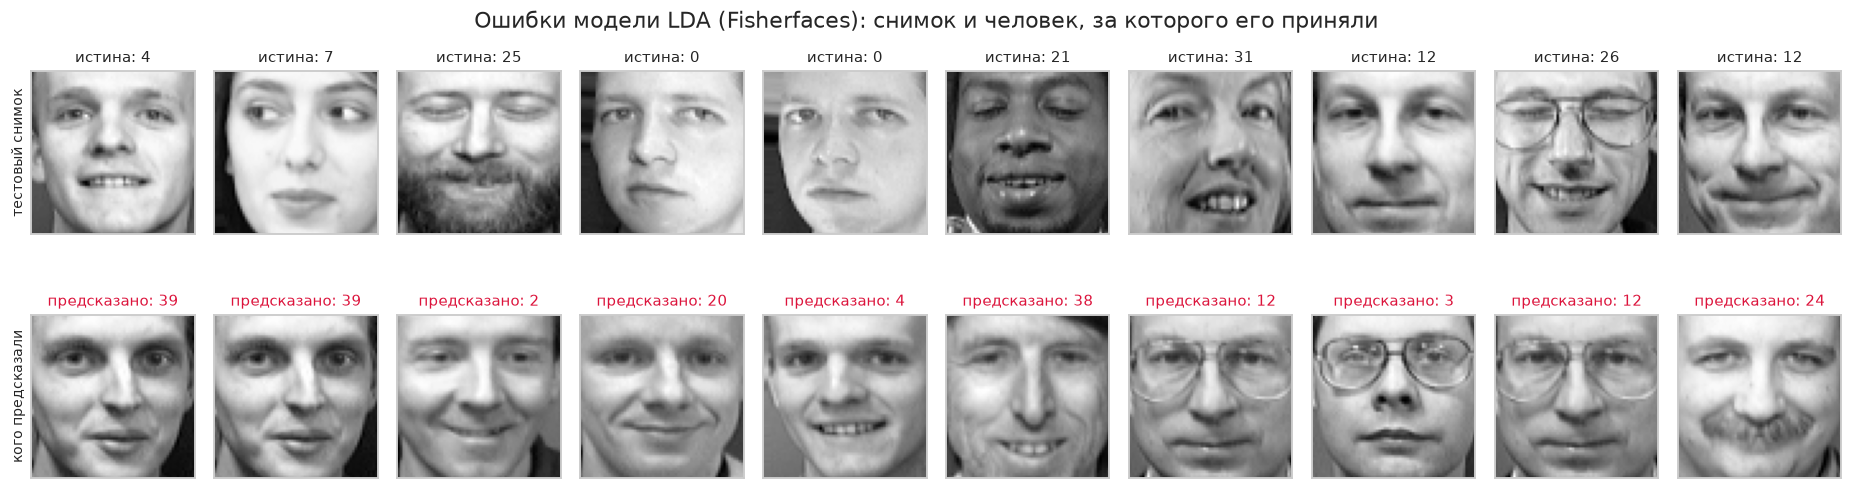

In [34]:
err_idx = np.where(y_best != y_test)[0]
err_nn = np.where(y_pred_nn != y_test)[0]
print("ошибок у {}: {} из {}".format(best_name, len(err_idx), len(y_test)))
print("ошибок у EigenFaceMLP: {}; общих снимков: {}".format(
    len(err_nn), len(set(err_idx.tolist()) & set(err_nn.tolist()))))

if len(err_idx) == 0:
    print("Ошибок нет — показывать нечего.")
else:
    n = len(err_idx)
    fig, axarr = plt.subplots(2, n, figsize=(1.7 * n, 4.6), squeeze=False)
    for j, i in enumerate(err_idx):
        axarr[0, j].imshow(X_test[i].reshape(64, 64), cmap="gray")
        axarr[0, j].set_title("истина: {}".format(y_test[i]), fontsize=10)

        # первый снимок человека, за которого модель приняла лицо
        wrong_id = y_best[i]
        axarr[1, j].imshow(data[wrong_id * 10], cmap="gray")
        axarr[1, j].set_title("предсказано: {}".format(wrong_id), fontsize=10, color="crimson")

        for r in (0, 1):
            axarr[r, j].set_xticks([]); axarr[r, j].set_yticks([])
    axarr[0, 0].set_ylabel("тестовый снимок", fontsize=9)
    axarr[1, 0].set_ylabel("кого предсказали", fontsize=9)
    plt.suptitle("Ошибки модели {}: снимок и человек, за которого его приняли".format(best_name))
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.35)
    plt.show()

### 6.3 Насколько уверена в своих ответах сеть

Этот раздел — **про `EigenFaceMLP`, а не про лучшую по CV модель**: именно у сети есть
осмысленные softmax-вероятности. Посмотрим, отличается ли уверенность на правильных
и ошибочных предсказаниях. Это практически важно: если ошибки идут с низкой уверенностью,
систему можно настроить на отказ от ответа вместо неправильного пропуска.

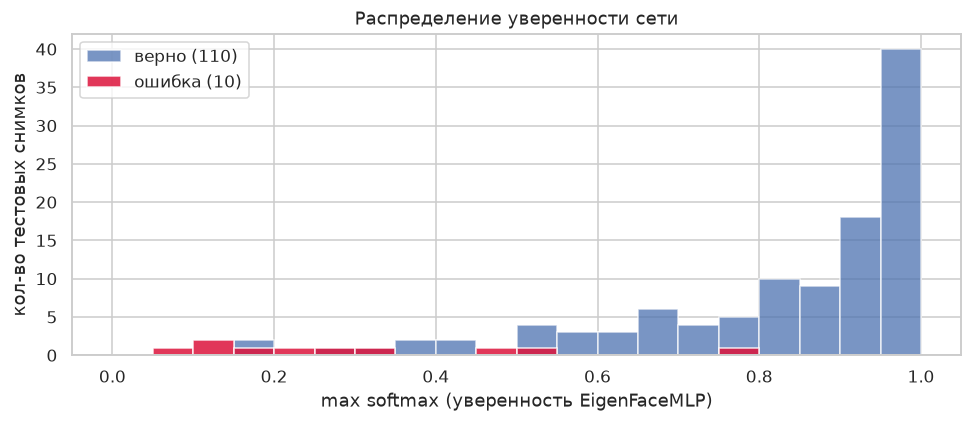

средняя уверенность на верных : 0.824
средняя уверенность на ошибках: 0.301
порог 0.5: отвечаем на  86.7% снимков, точность на них 0.981
порог 0.7: отвечаем на  72.5% снимков, точность на них 0.989
порог 0.9: отвечаем на  48.3% снимков, точность на них 1.000


In [35]:
conf = proba_test.max(1).values.cpu().numpy()
correct_mask = (y_pred_nn == y_test)

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 1, 21)
ax.hist(conf[correct_mask], bins=bins, alpha=.75, label="верно ({})".format(correct_mask.sum()))
ax.hist(conf[~correct_mask], bins=bins, alpha=.85, color="crimson",
        label="ошибка ({})".format((~correct_mask).sum()))
ax.set_xlabel("max softmax (уверенность EigenFaceMLP)")
ax.set_ylabel("кол-во тестовых снимков")
ax.set_title("Распределение уверенности сети")
ax.legend()
plt.tight_layout()
plt.show()

print("средняя уверенность на верных : {:.3f}".format(conf[correct_mask].mean()))
if (~correct_mask).sum():
    print("средняя уверенность на ошибках: {:.3f}".format(conf[~correct_mask].mean()))

for thr in (0.5, 0.7, 0.9):
    keep = conf >= thr
    if keep.sum():
        print("порог {:.1f}: отвечаем на {:>5.1f}% снимков, точность на них {:.3f}".format(
            thr, 100 * keep.mean(), metrics.accuracy_score(y_test[keep], y_pred_nn[keep])))

## 7. Выводы

### Итоговые цифры

Основной протокол — **вложенная кросс-валидация**: внешняя `RepeatedStratifiedKFold`
5×4 (20 оценок) на всех 400 снимках, внутри каждого внешнего фолда заново обучается
PCA(90, whiten) и заново подбираются гиперпараметры по внутренней 3-фолдовой CV.
Hold-out — исходное разбиение 280/120 из примера, одно случайное разбиение.
Гиперпараметры в скобках — те, что выбрались на hold-out-обучении; во вложенной CV
они переподбираются на каждом фолде.

| Модель (Feature Matching) | CV 5×4, mean ± std | hold-out | подбор ГП |
|---|---|---|---|
| **LDA (Fisherfaces)** | **0.983 ± 0.018** | 0.917 | 0.1 с |
| **EigenFaceMLP (наша сеть)** | **0.976 ± 0.016** | 0.917 | — (ГП фиксированы) |
| SVC (rbf, C=100, γ=0.001) | 0.971 ± 0.018 | 0.925 | 3.5 с |
| LogisticRegression (C=1) | 0.964 ± 0.017 | 0.917 | 0.04 с |
| RandomForest (500 деревьев) | 0.958 ± 0.020 | 0.925 | 12.6 с |
| KNN (k=1, cosine) | 0.956 ± 0.021 | 0.908 | 0.1 с |
| NearestCentroid | 0.953 ± 0.024 | 0.908 | 0.01 с |
| — базовая линия `SVC()` из примера | — | 0.917 | — |

### 1. PCA делает основную работу

4096 пикселей сжимаются до 90 компонент (в 45.5 раза) и удерживают 92.7 % дисперсии
датасета (93.7 % обучающей выборки). В этом пространстве **любой** из семи проверенных
классификаторов даёт ≥ 95 %: разрыв между лучшим и худшим — всего 3.1 п.п.
Это главный результат по части «оптимизации»: качественный Feature Extractor выравнивает
разницу между методами сопоставления, и дальше выбор классификатора — уже борьба
за последние проценты.

### 2. Лучший Feature Matching — LDA (Fisherfaces)

Попарное сравнение на 20 общих фолдах (раздел 6.1) показывает, насколько это устойчиво:

| LDA против | Δ accuracy | выиграл / ничья / проиграл |
|---|---|---|
| NearestCentroid | +0.031 | 20 / 0 / 0 |
| KNN | +0.028 | 17 / 2 / 1 |
| RandomForest | +0.025 | 17 / 2 / 1 |
| LogisticRegression | +0.019 | 15 / 4 / 1 |
| SVC | +0.013 | 12 / 6 / 2 |
| EigenFaceMLP | +0.007 | 8 / 10 / 2 |

Над всей классикой преимущество LDA систематическое — она выигрывает 15–20 фолдов
из 20. **А вот над нашей сетью преимущества нет**: 8 побед, 10 ничьих, 2 поражения —
это ровно то, что даёт случайный разброс. Разницу 0.983 против 0.976 трактовать
как превосходство нельзя.

Причина силы LDA содержательная: PCA ищет направления максимальной **дисперсии**,
а она в Olivetti в основном описывает освещение и поворот головы — то, что различает
*снимки*, а не *людей*. LDA поверх PCA ищет направления максимальной **разделимости
классов** и буквально выбрасывает «мешающие» оси. То есть выигрывает не более мощный
классификатор, а более уместное пространство признаков.

Побочный факт: `LinearDiscriminantAnalysis` был импортирован в исходном ноутбуке,
но ни разу не использован — самый сильный метод там просто остался за кадром.

### 3. Дефолтный `SVC()` из урока недонастроен

Базовая линия даёт 0.917 на hold-out; после `GridSearchCV` тот же `SVC` берёт
`C=100, gamma=0.001` (в 10 раз меньше дефолтного `scale` ≈ 0.011) и поднимается
до 0.925 на hold-out и 0.971 во вложенной CV. Дефолтное ядро при 90 whitened-компонентах
слишком узкое. Один прогон `GridSearchCV` за 3.5 секунды — самый дешёвый прирост
качества во всём ноутбуке.

Показательно, что **все лидеры — по сути линейные решающие правила**: LDA,
логистическая регрессия и SVC с очень широким rbf-ядром (γ=0.001 ведёт себя
почти линейно). При 6–8 обучающих снимках на человека линейная разделяющая
поверхность — ровно та ёмкость, которую можно надёжно оценить.

### 4. `NearestCentroid` — сильный бесплатный baseline, `RandomForest` — дорогой и средний

`NearestCentroid` не имеет ни одного обучаемого параметра (класс = ближайший средний
шаблон человека) и всё равно берёт 0.953 — в 2.4 п.п. от нейросети и в 3.1 п.п. от LDA.
Это хороший ориентир: если сложная модель не обходит центроиды заметно, она себя не окупает.

`RandomForest` даёт 0.958, но подбирался 12.6 с — в 100+ раз дольше LDA при худшем
качестве (а во вложенной CV он один съедает 161 с из 169). Деревья режут пространство
по отдельным осям, а информация о человеке размазана сразу по многим PCA-компонентам,
так что осевые разрезы здесь неэффективны.

### 5. Своя сеть — на уровне лучшей модели

`EigenFaceMLP` (62 120 параметров, 90 → 256 → 128 → 40) даёт **0.976 ± 0.016** и,
как показывает попарное сравнение, **статистически неотличима от LDA** — лучшего
метода в подборке. Классику она при этом обходит. Для 240 обучающих векторов
на 40 классов (по 6 на человека) это хороший результат, и достигается он только
за счёт регуляризации: BatchNorm + Dropout 0.4 + weight decay 1e-2 +
label smoothing 0.05 + гауссов шум σ=0.15 в пространстве eigenfaces.

Кривые обучения показывают, почему всё это обязательно: **train accuracy достигает
1.000 уже к 25-й эпохе** при train loss ≈ 0.46 против val loss ≈ 0.75 — сеть полностью
запомнила обучающую выборку, и дальше работает только регуляризация. Лучший чекпоинт
(эпоха 58, val loss 0.714) восстанавливается из истории, обучение останавливается
на 118-й эпохе.

Важная деталь протокола: чекпоинт отбирается **по val-loss, а не по val-accuracy**.
В валидации всего 40 объектов, точность меняется шагами по 2.5 %, десятки эпох дают
одно и то же значение — и «лучшей» становится первая попавшаяся ранняя эпоха.
Отбор по лоссу даёт эпоху 58 вместо ранней и на hold-out стабильно лучше.

Вывод: **сеть догоняет LDA, но не даёт прироста качества** — и при этом
требует GPU, 200 эпох и десяток гиперпараметров против одной строчки и 0.1 секунды
у LDA. Сравнение к тому же слегка в пользу сети: у классики гиперпараметры
переподбираются на каждом фолде, у сети они фиксированы на всех. При 8 снимках
на человека нелинейной модели просто нечего выучить сверх линейной границы.
Сеть оправдана как задел на будущее — когда снимков станет существенно больше
или когда вместо PCA появятся эмбеддинги предобученной свёрточной сети
(FaceNet/ArcFace), где нелинейной голове уже будет что моделировать.

### 6. Методология: hold-out обманывает, наивная CV завышает, средние не сравнивают

На hold-out все семь моделей укладываются в 0.908–0.925, то есть в диапазон
**двух снимков** (один снимок = 0.83 % точности). По этой таблице «лучшими» выглядят
`SVC` и `RandomForest` (0.925), хотя по 20 честным оценкам `RandomForest` — пятый.
Ранжировать модели по такому замеру нельзя.

Но и просто прогнать по кросс-валидации уже настроенные модели недостаточно:
их гиперпараметры подобраны на тех же объектах, которые затем попадут в тестовые фолды.
Поэтому здесь используется вложенная CV — `GridSearchCV` лежит **внутри** `Pipeline`,
и на каждом внешнем фолде PCA и гиперпараметры настраиваются заново. Утечки нет
ни на шаге извлечения признаков, ни на шаге подбора.

И третье: даже честные средние сравнивать «на глаз» нельзя. `std` в таблице посчитан
по фолдам, а не по разнице между моделями, и по нему кажется, что все различия тонут
в шуме. Попарное сравнение на общих фолдах снимает общую «сложность фолда» и даёт
ответ: разрыв LDA с классикой реален, а разрыв LDA с сетью — нет.

Кроме того, hold-out систематически ниже CV (0.917 против 0.983 у LDA) по двум причинам:
в нём 7 обучающих снимков на человека против 8 в 5-фолдовой CV, и это конкретное
разбиение оказалось трудным (класс 12 распознаётся с f1 = 0.33, класс 0 — recall 0.33).
Аналогично `NearestCentroid` показывает cv = 0.836 при подборе гиперпараметров
(5 фолдов от 280 объектов → 5.6 снимка на класс) и 0.953 в итоговой CV
(8 снимков на класс) — метод шаблонов резче всех реагирует на размер обучающей выборки.

### 7. Ошибки осмысленны, и их можно отфильтровать по confidence

У LDA 10 ошибок из 120, у сети — тоже 10, причём **9 из них приходятся на одни и те же
снимки**. То есть ошибаются модели не «каждая по-своему», а на объективно трудных кадрах:
это снимки с сильной мимикой (широкая улыбка, смех, зажмуренные глаза), заметным
поворотом головы, а также лица в очках и с бородой. Все эти факторы меняют изображение
сильнее, чем различаются два разных человека в нейтральной позе. Заодно это объясняет,
почему модели упираются в один и тот же потолок: ошибки идут не от слабости
классификатора, а от того, что в 6–8 снимках просто нет такой вариативности.

Softmax-уверенность сети (LDA откалиброванных вероятностей не даёт, поэтому раздел 6.3 —
про `EigenFaceMLP`) отделяет такие случаи очень чётко: средняя уверенность на верных
ответах **0.824**, на ошибочных — **0.301**. Отсюда практический режим с отказом:

| порог | доля снимков, на которые отвечаем | точность на них |
|---|---|---|
| 0.5 | 86.7 % | 0.981 |
| 0.7 | 72.5 % | 0.989 |
| 0.9 | 48.3 % | 1.000 |

При пороге 0.7 система отвечает на 72 % снимков с точностью 99 %. Для реальной СКУД
это правильный компромисс: лучше попросить переснять лицо, чем пустить не того человека.
Плюс top-3 accuracy сети равна 0.958 при top-1 = 0.917 — верный человек почти всегда
в тройке, что достаточно для сценария «подскажи оператору кандидатов».

### Итог

По качеству лидируют два решения, и **разницы между ними нет**: LDA (0.983 ± 0.018)
и наша сеть (0.976 ± 0.016). Выбор между ними решается не точностью, а ценой:

* **PCA(90, whiten) → LDA (Fisherfaces)** — обучение за 0.1 с, без GPU, без единого
  гиперпараметра. Это и есть рабочий вариант для Olivetti-подобной задачи;
* **PCA(90) → EigenFaceMLP** — то же качество ценой GPU и 200 эпох, но даёт
  калиброванную уверенность, а с ней режим отказа и top-3 — то, чего у LDA нет.

Иначе говоря, на данных такого объёма нейросеть окупается не точностью, а тем,
что вместе с ответом отдаёт меру доверия к нему.